In [14]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

In [17]:
from dotenv import load_dotenv
load_dotenv()

True

In [52]:
tavily_search  = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=True,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # start_date=None,
    # end_date=None,
    # include_domains=None,
    # exclude_domains=None,
    # include_usage= False
)

In [53]:
agent =create_agent(
    model=ChatOpenAI(model="gpt-4.1-mini"),
    tools=[tavily_search],
    system_prompt="""
You are a knowledgeable research assistant.

- Answer using your own knowledge whenever possible.
- Use the Tavily web search tool ONLY if:
  - The question requires recent or real-time information
  - You are unsure about the answer
  - The user explicitly asks for sources or latest updates

- Do NOT use the tool for common knowledge questions.
- When you use the tool, prefer reliable sources (e.g., Wikipedia if requested).
"""
)



In [27]:
response = agent.invoke({
    "messages": [{"role": "user", "content": "What is the most popular sport in the world? use tool"}]
})

In [28]:
response

{'messages': [HumanMessage(content='What is the most popular sport in the world? use tool', additional_kwargs={}, response_metadata={}, id='47d80782-5c24-4520-ad11-1ab7dec670eb'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1288, 'total_tokens': 1314, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_bb574964df', 'id': 'chatcmpl-DPnDIqb13sAPisxUkTPW8GqS5z8HZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d489d-182c-77d2-ba88-2ea9572d8d56-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'most popular sport in the world', 'search_depth': 'basic'}, 'id': 'call_CMq4Dr8aKP5KCx3lOQd2TXqX', 'ty

In [35]:
response['messages'][2]

ToolMessage(content='{"query": "most popular sport in the world", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.worldatlas.com/articles/what-are-the-most-popular-sports-in-the-world.html", "title": "The Most Popular Sports In The World - World Atlas", "content": "**The Most Popular Sports In The United States**By a large margin, the most popular sport in the United States is American Football, with over 188.4 million fans in the United States. Football (Soccer in the United States) is by far the world’s most popular sport, with 3.5 billion fans as of 2025. Hockey player Kemperman (NED) fencing off Brunet (ARG) during a charge at the Hockey World Cup. Hockey is a diverse and competitive team sport with roughly two billion fans. The World Cup, Olympic Games, and Pro League are just a few of the top events involving the sport. Tennis is the most famous racket sport in the world, and it has over a billion fans across the globe. With its ease an

In [38]:
import json

tool_msg = response["messages"][2]

data = json.loads(tool_msg.content)

print(json.dumps(data, indent=2))

{
  "query": "most popular sport in the world",
  "follow_up_questions": null,
  "answer": null,
  "images": [],
  "results": [
    {
      "url": "https://www.worldatlas.com/articles/what-are-the-most-popular-sports-in-the-world.html",
      "title": "The Most Popular Sports In The World - World Atlas",
      "content": "**The Most Popular Sports In The United States**By a large margin, the most popular sport in the United States is American Football, with over 188.4 million fans in the United States. Football (Soccer in the United States) is by far the world\u2019s most popular sport, with 3.5 billion fans as of 2025. Hockey player Kemperman (NED) fencing off Brunet (ARG) during a charge at the Hockey World Cup. Hockey is a diverse and competitive team sport with roughly two billion fans. The World Cup, Olympic Games, and Pro League are just a few of the top events involving the sport. Tennis is the most famous racket sport in the world, and it has over a billion fans across the glob

In [41]:
ai_msg = response["messages"][3]
print(ai_msg.content)

The most popular sport in the world is soccer (also known as football), with about 3.5 billion fans globally as of 2025. It is the most-watched sport worldwide, with major events like the FIFA World Cup attracting billions of viewers.


In [43]:
response = agent.invoke({
    "messages": [{"role": "user", "content": "What is the most popular sport in the world?"}]
})

In [45]:
response

{'messages': [HumanMessage(content='What is the most popular sport in the world?', additional_kwargs={}, response_metadata={}, id='b0731ce2-1d6f-4aa1-aa07-5f649a77c57d'),
  AIMessage(content="The most popular sport in the world is soccer (also known as football in most countries outside the United States and Canada). Soccer has the largest global following in terms of both participants and fans. It is played and watched by millions of people across almost every country, making it the world's most popular and widely recognized sport.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1286, 'total_tokens': 1350, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b6b587afe3', 'id

In [54]:
response = agent.invoke({
    "messages": [{"role": "user", "content": "What is the next kerala assembly election date?"}]
})

In [55]:
response

{'messages': [HumanMessage(content='What is the next kerala assembly election date?', additional_kwargs={}, response_metadata={}, id='b203577a-5270-446d-a9aa-98f72d30e543'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1286, 'total_tokens': 1311, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c5385b4086', 'id': 'chatcmpl-DPnjFb76UV2cERSyLOBXpQapmn5e4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d48bb-541b-7942-b94c-01a358354c8b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'next Kerala assembly election date', 'time_range': 'year'}, 'id': 'call_TRLrLIoMuMVR4NplXHMYP7yD', 'type': 'too

In [56]:
import json

tool_msg = response["messages"][2]

data = json.loads(tool_msg.content)

print(json.dumps(data, indent=2))

{
  "query": "next Kerala assembly election date",
  "response_time": 0.77,
  "follow_up_questions": null,
  "answer": "The Kerala Assembly election will take place on April 9, 2026, with results announced on May 4, 2026. The election will be conducted in a single phase.",
  "images": [],
  "results": [
    {
      "url": "https://www.thehindu.com/elections/kerala-assembly/kerala-assembly-elections-2026-dates-full-schedule/article70746415.ece",
      "title": "Kerala Assembly elections 2026: full schedule - The Hindu",
      "content": "News and reviews from the world of cinema and streaming. # Kerala Assembly elections 2026: full schedule. The Election Commission of India (ECI) announced the much-awaited election schedule for the Kerala Assembly election on Sunday (March 15, 2026). The State will hold polling in a single phase on April 9, 2026, with vote counting scheduled for May 4, 2026. ****Also read: Assembly elections 2026 schedule highlights****. Kerala, currently governed by th

# langgraph

In [61]:
llm= ChatOpenAI(model="gpt-4.1-mini")

In [60]:
from langgraph.graph import StateGraph
from langgraph.graph import START, END

from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition

In [51]:
from typing import TypedDict

class AgentState(TypedDict):
    question: str
    search_results: dict  
    answer: str

In [78]:
import os
from tavily import TavilyClient

# Initialize Tavily client  
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [66]:
@tool
def search_web(query:str):
    """
    Intelligent Web Search

    Uses Tavily's AI-optimized search to find and process web information.
    Behind the scenes: Tavily searches multiple sources, extracts relevant content,
    and uses AI to synthesize the information into a coherent answer.
    """
    return tavily.search(
        query=query,
        max_results=3,
        include_answer=True
    )

tools = [search_web]
llm_with_tools = llm.bind_tools(tools)

In [70]:
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a smart AI assistant.

Guidelines:
- Answer using your own knowledge whenever possible.
- Use the `search_web` tool ONLY if:
  - The question requires recent or real-time information
  - You are unsure about the answer
  - The user asks for latest updates or sources

- Do NOT use the tool for common knowledge.
- When using the tool, include sources in your answer.
"""),
    ("placeholder", "{messages}")
])

In [71]:
from langgraph.graph import MessagesState

class State(MessagesState):
    pass

def chatbot(state: State):
    # Format messages with prompt
    formatted_messages = prompt.invoke({
        "messages": state["messages"]
    })

    # Call LLM with tools
    response = llm_with_tools.invoke(formatted_messages)

    return {"messages": [response]}
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

graph = builder.compile()

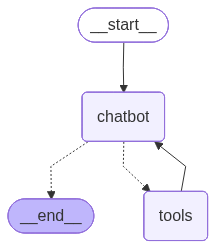

In [72]:
graph

In [75]:
from langchain_core.messages import HumanMessage

response = graph.invoke({
    "messages": [
        HumanMessage(content="What is the most popular sport in the world?")
    ]
})

In [76]:
response

{'messages': [HumanMessage(content='What is the most popular sport in the world?', additional_kwargs={}, response_metadata={}, id='1fe876a7-a385-4f94-9333-eb032997f7fb'),
  AIMessage(content="The most popular sport in the world is soccer (also known as football in most countries). It has the largest global following, with billions of fans and participants across every continent. The sport's simplicity, minimal equipment needs, and widespread professional leagues contribute to its immense popularity. Major events like the FIFA World Cup attract huge viewership worldwide.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 177, 'total_tokens': 245, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'syste

In [79]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="What is the next kerala assembly election date?")
    ]
})

In [80]:
response

{'messages': [HumanMessage(content='What is the next kerala assembly election date?', additional_kwargs={}, response_metadata={}, id='72e0ff5c-ab1a-43c0-bc53-824711b3a91d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 177, 'total_tokens': 195, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c5385b4086', 'id': 'chatcmpl-DPorDXxWlv2jPBA8sfjdJx0jxrznd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d48fd-826e-71f0-98cd-7fed991874ec-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'next Kerala assembly election date'}, 'id': 'call_91k4rGGOEOHWYqvSXoxUnPds', 'type': 'tool_call'}], invalid_tool_cal

In [81]:
import json

tool_msg = response["messages"][2]

data = json.loads(tool_msg.content)

print(json.dumps(data, indent=2))

{
  "query": "next Kerala assembly election date",
  "follow_up_questions": null,
  "answer": "The Kerala Assembly election 2026 will be held on April 9, with results announced on May 4. The nomination deadline is March 23, 2026. The election will be a single phase.",
  "images": [],
  "results": [
    {
      "url": "https://www.thehindu.com/elections/kerala-assembly/kerala-assembly-elections-2026-dates-full-schedule/article70746415.ece",
      "title": "Kerala Assembly elections 2026: full schedule - The Hindu",
      "content": "News and reviews from the world of cinema and streaming. # Kerala Assembly elections 2026: full schedule. The Election Commission of India (ECI) announced the much-awaited election schedule for the Kerala Assembly election on Sunday (March 15, 2026). The State will hold polling in a single phase on April 9, 2026, with vote counting scheduled for May 4, 2026. ****Also read: Assembly elections 2026 schedule highlights****. Kerala, currently governed by the Lef